## Exploratory Data Analysis

### Install and Import Libraries

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3

### Load and Preview the Dataset

In [3]:
# Loading and Database connection

# read csv
df_csv = pd.read_csv("cleaned_data.csv")

# save to sql 
conn = sqlite3.connect("cleaned_data.db")
df_csv.to_sql("survey_data", conn, if_exists = "replace", index=False)

# Query from sql
df = pd.read_sql_query("select * from survey_data", conn)

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,ConvertedCompYearly_MinMax,ConvertedCompYearly_Zscore,ConvertedCompYearly_Log,ExperienceLevel
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/Elementary School,Books / Physical media,None,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,junior
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’S Degree (B.A., B.S., B.Eng., Etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,None,None,NaN,NaN,NaN,NaN,NaN,Senior
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’S Degree (M.A., M.S., M.Eng., Mba, Etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,Appropriate in length,Easy,NaN,NaN,NaN,NaN,NaN,Expert
3,4,I am learning to code,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Other...,Some College/University Study Without Earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,Too long,Easy,NaN,NaN,NaN,NaN,NaN,junior
4,5,I am a developer by profession,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Other...,"Secondary School (E.G. American High School, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,Too short,Easy,NaN,NaN,NaN,NaN,NaN,junior


## Handling Missing Data
Identify and manage missing values in critical columns such as Employment, JobSat, and RemoteWork. Implement a strategy to fill or drop these values, depending on the significance of the missing data.

In [4]:
cricital_col = ["Employment", "JobSat", "RemoteWork"]

# count missing value
missing_value = df[cricital_col].isna().sum()
missing_value

Employment        0
JobSat        36311
RemoteWork        0
dtype: int64

In [5]:
# drop value from Employment
df = df.dropna(subset=["Employment"])

In [6]:
# handle missing value from Jobsat
mode_jobsat = df["JobSat"].mode()[0]
df["JobSat"] = df["JobSat"].fillna(mode_jobsat)

In [7]:
# verify cricital columns
df[cricital_col].isna().sum()

Employment    0
JobSat        0
RemoteWork    0
dtype: int64

Split the data 

### Visualize Job Satisfaction
- Use a count plot to show the distribution of JobSat values. This provides insights into the overall satisfaction levels of respondents.
- Create a pie chart to visualize the distribution of JobSat.

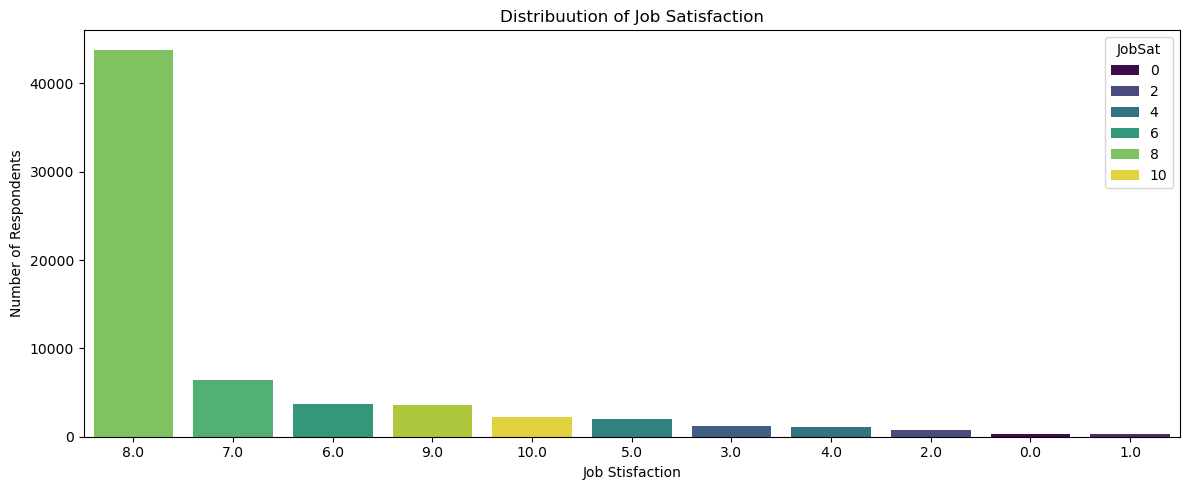

In [8]:
plt.figure(figsize=(12,5))
sns.countplot(x="JobSat", data=df, order=df["JobSat"].value_counts().index, hue="JobSat", palette = "viridis")

plt.title("Distribuution of Job Satisfaction")
plt.xlabel("Job Stisfaction")
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

Create a pie chart to visualize the distribution of JobSat.

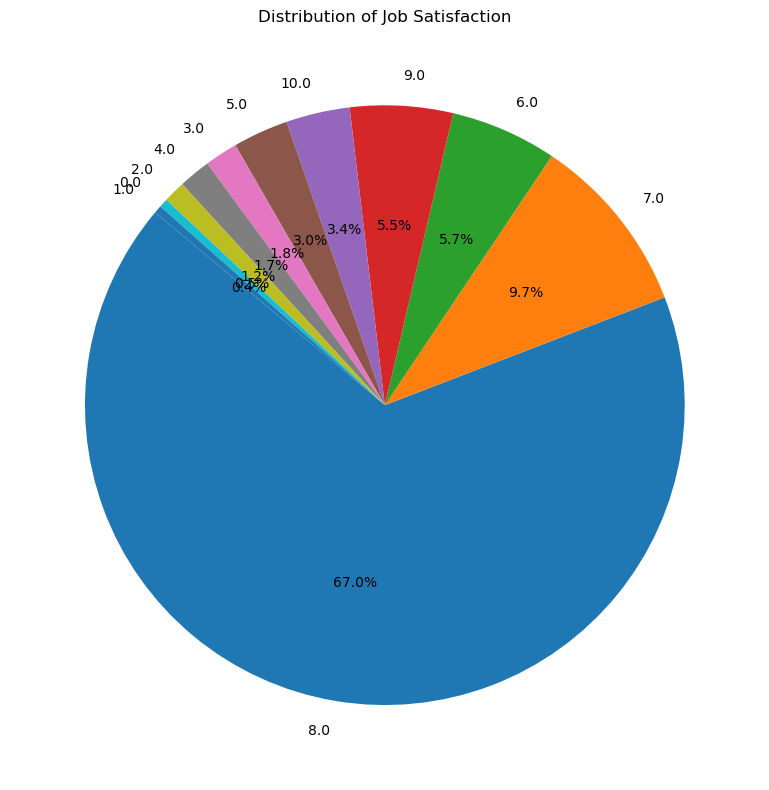

In [9]:
job_sat_counts = df["JobSat"].value_counts()

# plot the chart
plt.figure(figsize=(12,8))
plt.pie(job_sat_counts, labels= job_sat_counts.index, autopct="%1.1f%%", startangle=140)
plt.title('Distribution of Job Satisfaction')
plt.tight_layout()
plt.show()

### Analyzing Remote Work Preferences by Job Role
Analyze trends in remote work based on job roles. Use the RemoteWork and Employment columns to explore preferences and examine if specific job roles prefer remote work more than others.

Use a count plot to show remote work distribution.

Cross-tabulate remote work preferences by employment type (e.g., full-time, part-time) and job roles.

In [10]:
# Count of each remote work type per job role
remote_trands = df.groupby(["Employment", "RemoteWork"]).size().unstack(fill_value=0)
remote_trands.head()

RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Employment,,,
"Employed, full-time",17296,8552,13193
"Employed, full-time;Employed, part-time",85,32,95
"Employed, full-time;Independent contractor, freelancer, or self-employed",1330,366,1861
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time",80,17,87
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired",0,1,0


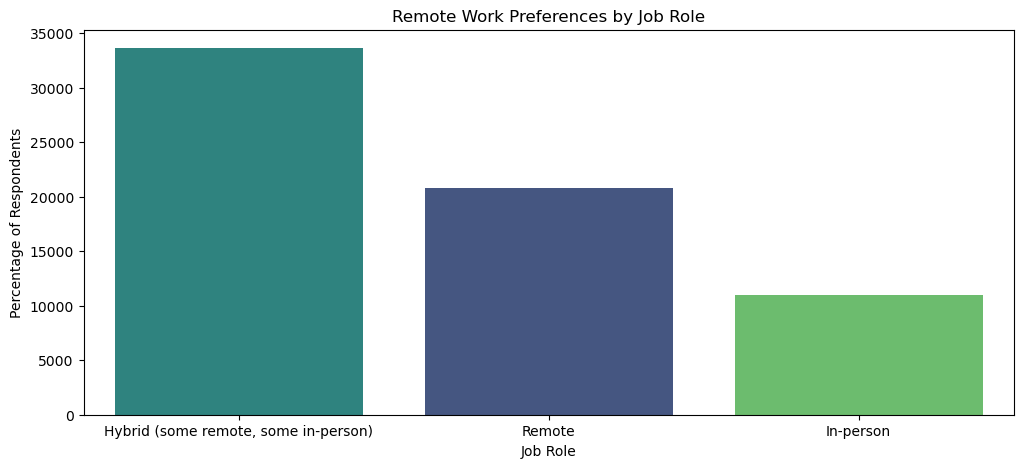

In [11]:
# count plot to show remote work distribution.

plt.figure(figsize=(12,5))
sns.countplot(x="RemoteWork",data=df,order=df["RemoteWork"].value_counts().index, hue = "RemoteWork",palette="viridis")

plt.title('Remote Work Preferences by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Percentage of Respondents')
plt.show()

In [12]:
# Cross-tabulate remote work preferences by employment type (e.g., full-time, part-time) and job roles.

cross_tab = pd.crosstab(index=df["Employment"],columns = df["RemoteWork"],margins = True)
cross_tab.head()

RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote,All
Employment,,,,
"Employed, full-time",17296,8552,13193,39041
"Employed, full-time;Employed, part-time",85,32,95,212
"Employed, full-time;Independent contractor, freelancer, or self-employed",1330,366,1861,3557
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time",80,17,87,184
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired",0,1,0,1


### Programming Languages Analysis

Compare the frequency of programming languages in LanguageHaveWorkedWith and LanguageWantToWorkWith.

Visualize the overlap or differences using a Venn diagram or a grouped bar chart.

In [13]:
df_lang_compare = df[['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']].dropna().copy()

df_lang_compare['LanguageHaveWorkedWith'] = df_lang_compare['LanguageHaveWorkedWith'].str.split(",")
df_lang_compare['LanguageWantToWorkWith'] = df_lang_compare['LanguageWantToWorkWith'].str.split(",")

In [14]:
# Languages respondents have worked with
have_counts = (
    df_lang_compare['LanguageHaveWorkedWith']
    .explode()
    .value_counts()
)

# Languages respondents want to work with
want_counts = (
    df_lang_compare['LanguageWantToWorkWith']
    .explode()
    .value_counts()
)

# Combine both counts into one comparison table
language_comparison = pd.DataFrame({
    'Have Worked With': have_counts,
    'Want To Work With': want_counts
}).fillna(0).astype(int)

language_comparison.head(5)

,Have Worked With,Want To Work With
Ada,40,54
Ada;Apex,6,4
Ada;Apex;Assembly,2,2
Ada;Apex;Assembly;Bash/Shell (all shells),0,1
Ada;Apex;Assembly;Bash/Shell (all shells);C#,0,1


Visualize the overlap or differences using a Venn diagram or a grouped bar chart

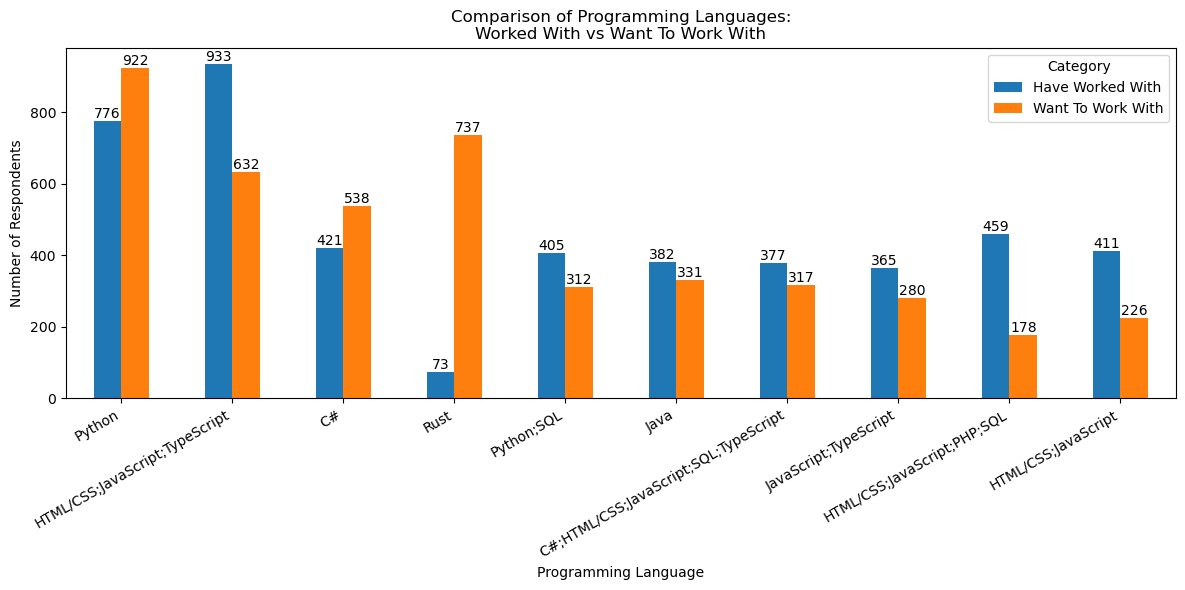

In [15]:
top_10_langs= language_comparison.sum(axis=1).sort_values(ascending=False).head(10).index

plot_data = language_comparison.loc[top_10_langs]

# plot the data
ax = plot_data.plot(kind="bar", figsize=(12,6))

plt.title('Comparison of Programming Languages:\nWorked With vs Want To Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=30, ha="right")
plt.legend(title='Category')
plt.tight_layout()

# ADD VALUE LABELS
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

## Correlation between Job Satisfaction and Experience
Analyze the correlation between overall job satisfaction (JobSat) and YearsCodePro.

Calculate the Pearson or Spearman correlation coefficient

Use a scatter plot to visualize this relationship.

In [16]:
df_corr = df[["JobSat", "YearsCodePro"]]

In [17]:
# Pearson Corr relation 
pearson_corr = df_corr["JobSat"].corr(df_corr["YearsCodePro"],method="pearson")
print(f"Pearson Corr relation coefficient: {pearson_corr}")

Pearson Corr relation coefficient: 0.039889812360781124


In [18]:
# Spearman Cor relation
pearman_corr = df_corr["JobSat"].corr(df_corr["YearsCodePro"],method="spearman")
print(f"Spearman Corr relation coefficient: {pearman_corr}")

Spearman Corr relation coefficient: 0.05274816289394541


Use a scatter plot to visualize this relationship.

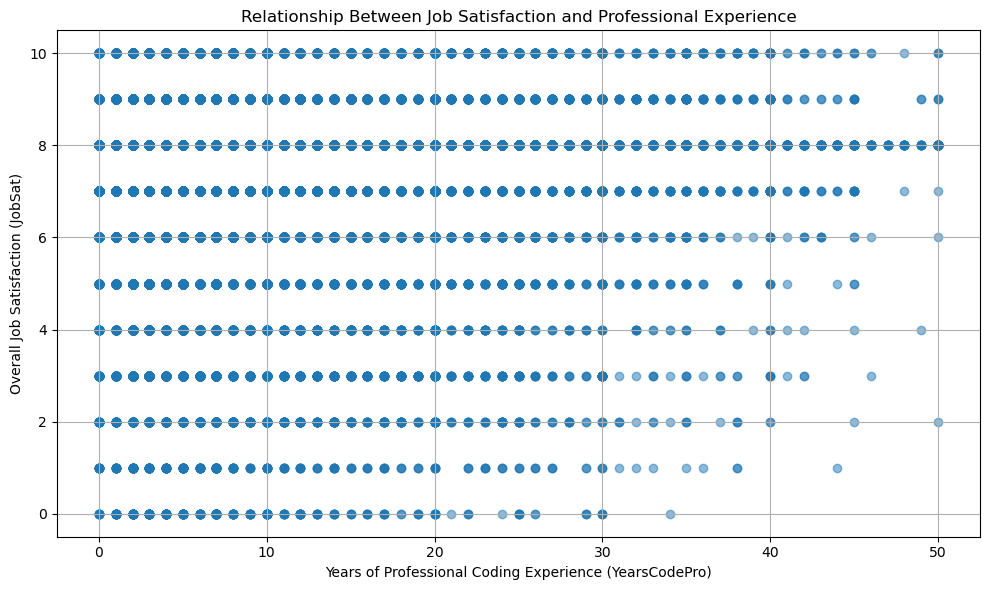

In [19]:
# scatter plot to visualize this relationship.
plt.figure(figsize=(10, 6))

plt.scatter(df_corr["YearsCodePro"],df_corr["JobSat"],alpha=0.5)

plt.xlabel("Years of Professional Coding Experience (YearsCodePro)")
plt.ylabel("Overall Job Satisfaction (JobSat)")
plt.title("Relationship Between Job Satisfaction and Professional Experience")


plt.grid(True)
plt.tight_layout()
plt.show()


- Loaded and explored the structure of the dataset.

- Handled missing data effectively.

- Analyzed key variables, including working hours, job satisfaction, and remote work trends.

- Investigated programming language usage by region and examined the relationship between experience and satisfaction.

- Used cross-tabulation to understand educational background and employment type.

### Analyzing Compensation Range and Distribution by Country
Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.

In [20]:
comp_df = df[['Country', 'ConvertedCompYearly']].dropna()

# Select top 10 countries by number of respondents
top_countries = comp_df['Country'].value_counts().head(10).index

comp_df = comp_df[comp_df['Country'].isin(top_countries)]

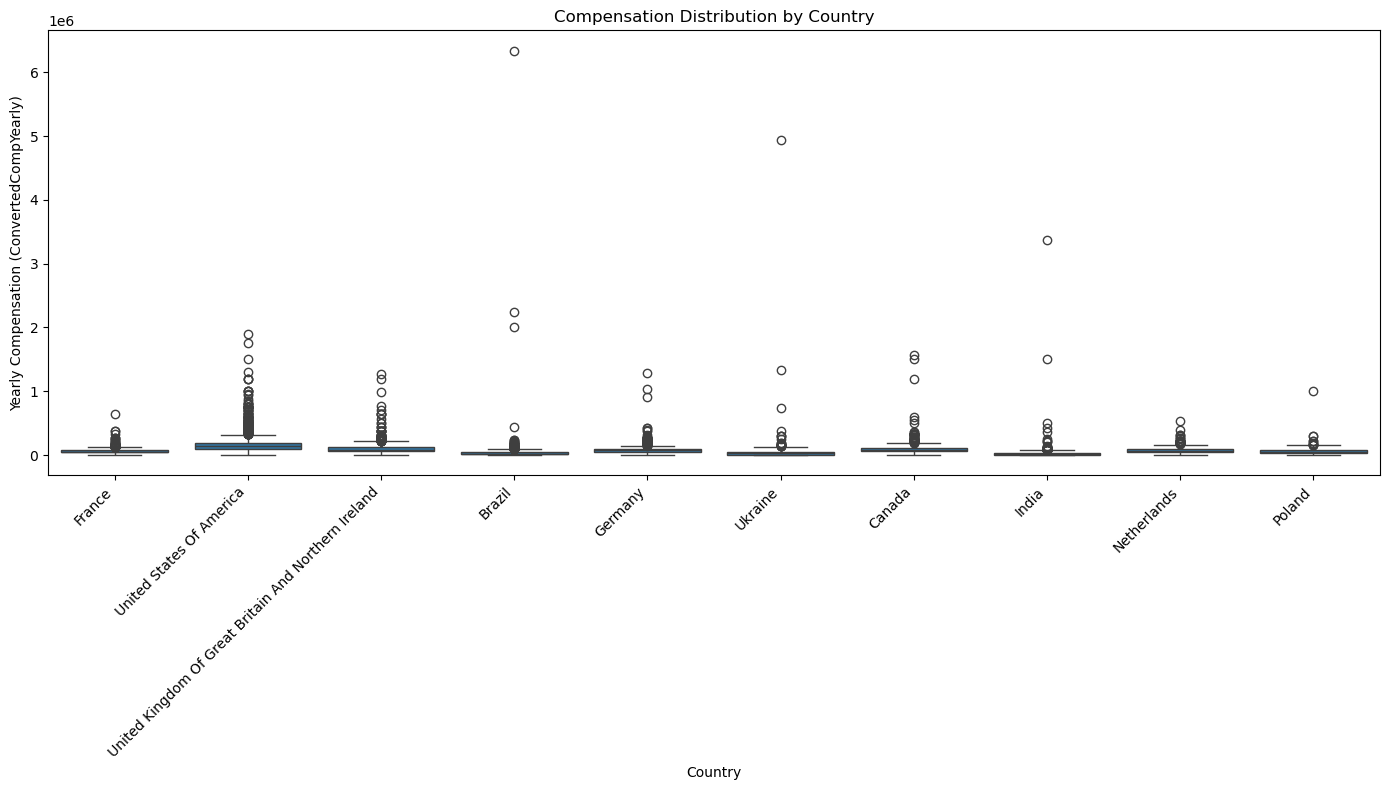

In [21]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=comp_df,x='Country',y='ConvertedCompYearly')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Country")
plt.ylabel("Yearly Compensation (ConvertedCompYearly)")
plt.title("Compensation Distribution by Country")
plt.tight_layout()
plt.show()

##  Identify High Compensation Outliers
Calculate basic statistics (mean, median, and standard deviation) for ConvertedCompYearly.

Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).

In [22]:
mean_salary = df["ConvertedCompYearly"].mean()
median_salary = df["ConvertedCompYearly"].median()
std_salary= df["ConvertedCompYearly"].std()

# create threshold 
threshold = mean_salary + 3 * std_salary
print(f"Threshold VVlue : {threshold}")

Threshold VVlue : 646426.2065215267


In [23]:
high_comp_outliers = df["ConvertedCompYearly"] > threshold
print(f"Number of outliers : {high_comp_outliers.shape[0]}")
df[high_comp_outliers].head(2)

Number of outliers : 65437


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,ConvertedCompYearly_MinMax,ConvertedCompYearly_Zscore,ConvertedCompYearly_Log,ExperienceLevel
529,530,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’S Degree (B.A., B.S., B.Eng., Etc.)","Books / Physical media;School (i.e., Universit...",None,...,10.0,0.0,Appropriate in length,Easy,650000.0,6.0,0.039984,3.019136,13.384729,Mid
828,829,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Bootstrapping a business;Professional de...,"Master’S Degree (M.A., M.S., M.Eng., Mba, Etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,Appropriate in length,Neither easy nor difficult,1000000.0,8.0,0.061513,4.893229,13.815512,Senior


## Detect Outliers in Compensation
Identify outliers in the ConvertedCompYearly column using the IQR method.

Calculate the Interquartile Range (IQR).

Determine the upper and lower bounds for outliers.

Count and visualize outliers using a box plot.

In [24]:
# Calculate the Interquartile Range (IQR).
Q1 = df["ConvertedCompYearly"].quantile(.25)
Q3 = df["ConvertedCompYearly"].quantile(.75)

#Interquartile Range (IQR).
IQR = Q3 - Q1

# Determine the upper and lower bounds for outliers.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q1 + 1.5 * IQR

print(f"Interquartile Range : {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")


Interquartile Range : 75259.50
Lower bound: -80177.25
Upper bound: 145601.25


In [25]:
outliers = df[
    (df['ConvertedCompYearly'] < lower_bound) |
    (df['ConvertedCompYearly'] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 3310


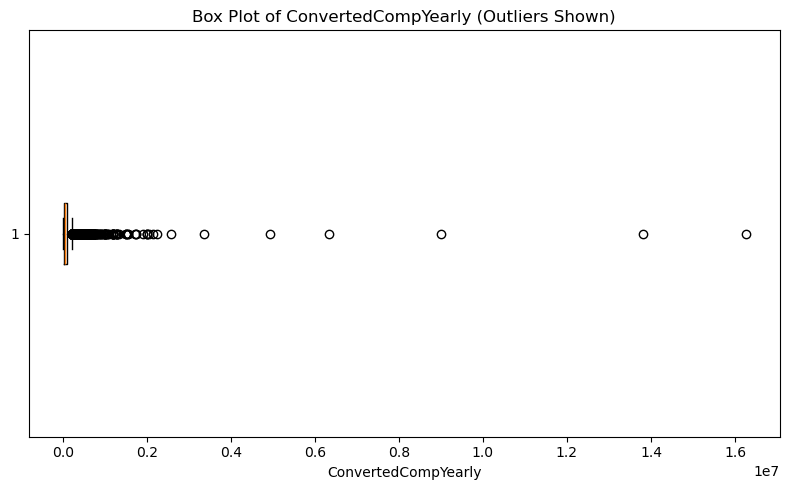

In [26]:
# Count and visualize outliers using a box plot.
plt.figure(figsize=(8, 5))
plt.boxplot(df['ConvertedCompYearly'].dropna(),vert=False)
plt.xlabel('ConvertedCompYearly')
plt.title('Box Plot of ConvertedCompYearly (Outliers Shown)')
plt.tight_layout()
plt.show()

### Remove Outliers and Create a New DataFrame
Remove outliers from the dataset.

Create a new DataFrame excluding rows with outliers in ConvertedCompYearly.

Validate the size of the new DataFrame.

In [27]:
# Create a new DataFrame without outliers
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) 
    &(df['ConvertedCompYearly'] <= upper_bound)].copy()

# Verify result
print("Original rows:", df.shape[0])
print("Rows after removing outliers:", df_no_outliers.shape[0])

Original rows: 65437
Rows after removing outliers: 20125


In [28]:
# Validate the size of the new DataFrame.
rows_removed = df.shape[0] - df_no_outliers.shape[0]
print("Rows removed as outliers:", rows_removed)

Rows removed as outliers: 45312


- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the Age column into numeric values for better analysis.

### Correlation Analysis
Analyze the correlation between Age (transformed) and other numerical columns.

Map the Age column to approximate numeric values.

Compute correlations between Age and other numeric variables.

Visualize the correlation matrix.

Task: Calculate correlations between ConvertedCompYearly, WorkExp, and JobSatPoints_1. Visualize these correlations with a heatmap.

In [29]:
cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']

corr_data = df[cols].apply(pd.to_numeric, errors='coerce').dropna()

corr_matrix = corr_data.corr(method='spearman')
corr_matrix

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.480900,0.033469
WorkExp,0.480900,1.000000,0.050406
JobSatPoints_1,0.033469,0.050406,1.000000


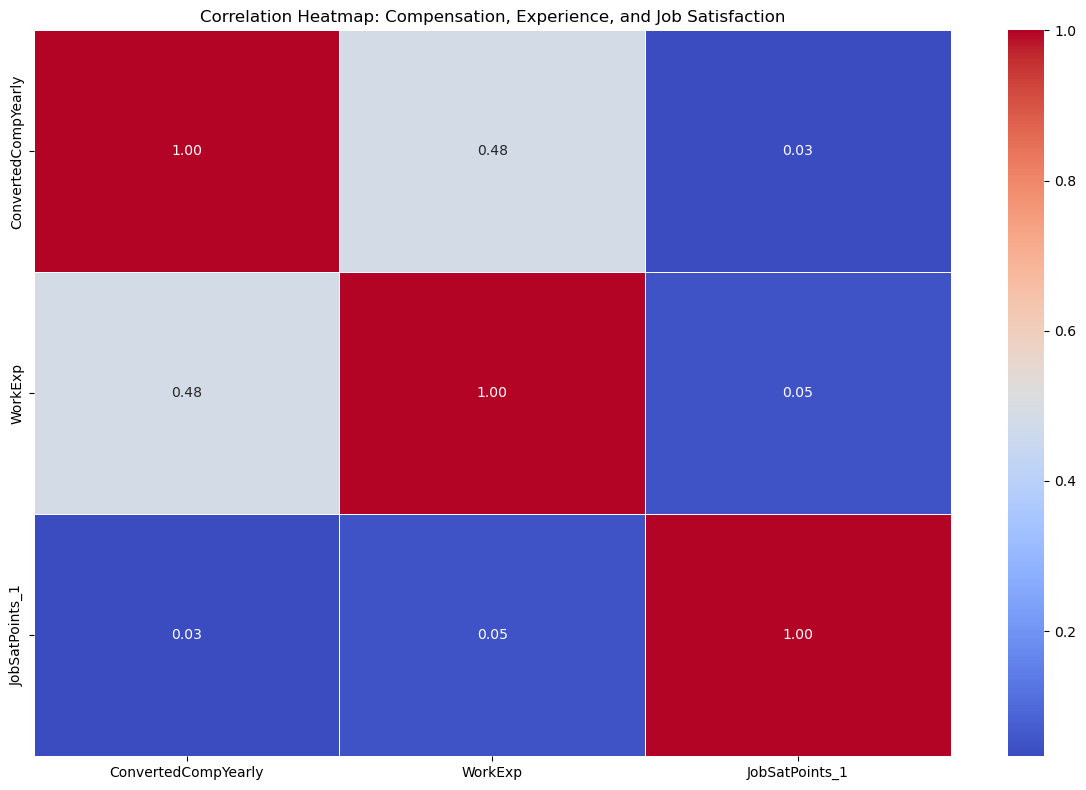

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)

plt.title("Correlation Heatmap: Compensation, Experience, and Job Satisfaction")

plt.tight_layout()
plt.show()


In [31]:
df["Age"].unique()

array(['Under 18 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '25-34 years old', '55-64 years old',
       'Prefer not to say', '65 years or older'], dtype=object)

In [32]:
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 30,
    "35-44 years old": 40,
    "45-54 years old": 50,
    "55-64 years old": 60,
    "65 years or older": 70,
    "Prefer not to say": None   # or np.nan
}

df['Age_num'] = df['Age'].map(age_map)

In [33]:
df['Age_num'] = pd.to_numeric(df['Age_num'], errors='coerce')
df = df.dropna(subset=['Age_num'])

In [34]:
# Compute correlations between Age and other numeric variables.
num_col = df.select_dtypes(include="number").columns
# praepre data for correlation 
corr_df = df[num_col].dropna().copy()

# Compute correlations with Age (RECOMMENDED: Spearman)

age_spearman_corr = (corr_df.corr(method='spearman')['Age_num'].sort_values(ascending=False))
print(f"Compute correlations with Age  : \n{age_spearman_corr.transpose()}")

Compute correlations with Age  : 
Age_num                       1.000000
WorkExp                       0.808944
YearsCodePro                  0.772920
ConvertedCompYearly           0.412636
ConvertedCompYearly_Log       0.412636
ConvertedCompYearly_Zscore    0.412636
ConvertedCompYearly_MinMax    0.412636
CompTotal                     0.125983
JobSat                        0.072879
JobSatPoints_1                0.018859
JobSatPoints_6               -0.009141
JobSatPoints_8               -0.009304
JobSatPoints_4               -0.030743
ResponseId                   -0.044791
JobSatPoints_7               -0.046593
JobSatPoints_9               -0.049356
JobSatPoints_5               -0.056146
JobSatPoints_11              -0.078245
JobSatPoints_10              -0.097910
Name: Age_num, dtype: float64


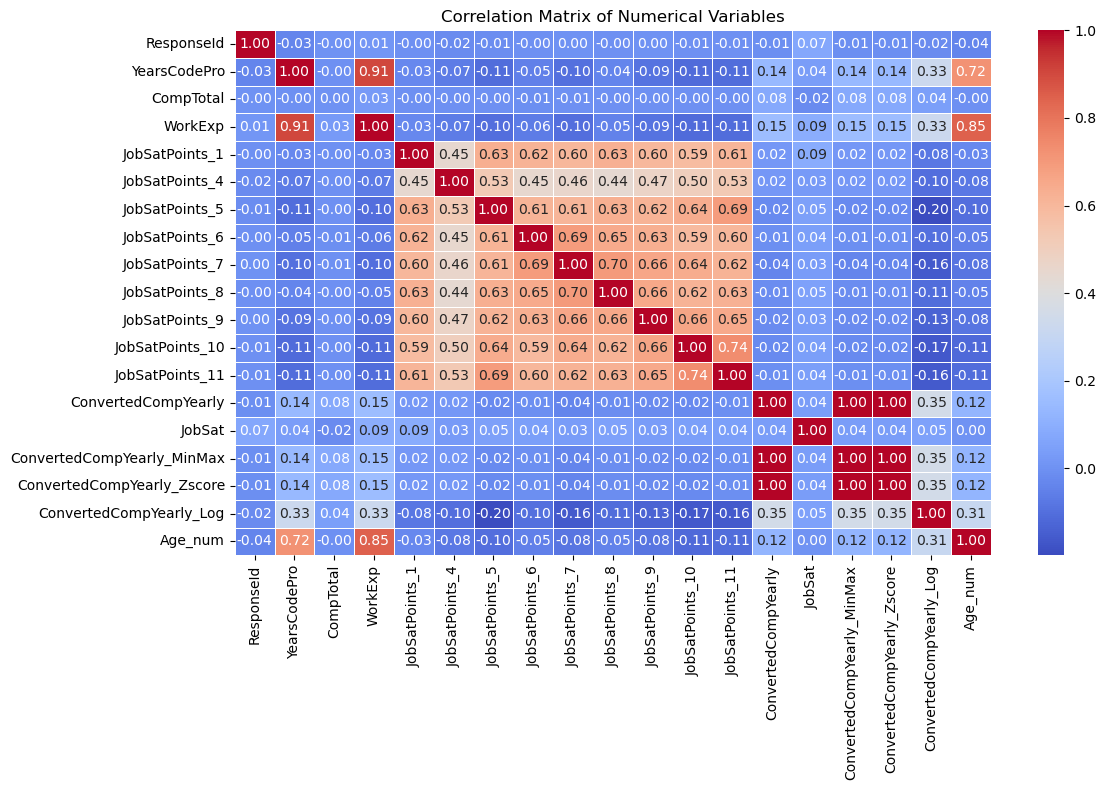

In [35]:
# Visualize the correlation matrix.
corr_matrix = df.select_dtypes(include='number').corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

In [36]:
# Save the data 
df.to_csv("Exploratory_Data.csv", index=False)

In [37]:
conn.close()